# Analyse Tau A — extinction poussière, cubes HI/CO et faisceaux NenuFAR

## Objectif
Ce notebook regroupe les étapes de préparation, de visualisation et de comparaison entre :

- les cartes d'extinction de poussière 3D ;
- les cubes spectraux HI et CO ;
- les champs de vue/faisceaux NenuFAR à différentes fréquences ;
- plusieurs lignes de visée autour de Tau A.

## Notes de reproductibilité
Les cellules ont été conservées dans l'ordre d'origine afin de limiter les risques de changement de résultat. Les sorties ont été supprimées, les cellules vides retirées, et les cellules de diagnostic rapide ont été signalées.

Dépendances externes attendues : modules locaux `maps`, `calcul`, `graphics`, `reid19_rotcurve`, fichier `dust_map.nc`, fichier `../Taua-obslog.csv`, et accès éventuel aux cubes HI/CO via les fonctions du module `maps`.


In [1]:
%matplotlib widget

# Accès aux modules locaux du projet.
import os
import sys

# sys.path management removed — install with: pip install -e .

import matplotlib.pyplot as plt


In [2]:
# Imports scientifiques et modules projet.
from astropy.io import fits
from astropy.coordinates import SkyCoord, BaseCoordinateFrame
from astropy.time import Time, TimeDelta
import astropy.units as u

import os
import warnings

import matplotlib
import numpy as np
import pandas as pd
import scipy
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from skimage import measure
from tqdm import tqdm

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from nenupy.instru import MiniArray, NenuFAR, Polarization, NenuFAR_Configuration
from nenupy.astro.sky import HpxSky, Sky
from nenupy.astro.pointing import Pointing
from nenupy.astro.target import FixedTarget, SolarSystemTarget

# Modules locaux du projet.
import spectral_tools.reid19_rotcurve as reid19_rotcurve
import spectral_tools.graphics as graphics
import spectral_tools.maps as maps
import spectral_tools.tools as tools


## Fonctions utilitaires


In [5]:
#from spectral_tools.line_fitting import _gaussian as gauss


def get_length_clouds(
    extinctions,
    kselect=0,
    large=None,
    rad=30,
    flags=None,
    flagauss=None,
    gaussian=False,
    small=None,
):
    """Détecte les pics d'extinction et estime leur largeur.

    Parameters
    ----------
    extinctions : array-like
        Profil d'extinction le long de la ligne de visée.
    kselect : int, optional
        Indice du pic à annoter en détail sur l'axe courant `ax`.
    large, small : list[int], optional
        Indices de pics nécessitant respectivement une fenêtre plus large ou plus étroite.
    rad : int, optional
        Demi-largeur de la fenêtre de recherche autour de chaque pic.
    flags : list[int], optional
        Indices de pics à exclure.
    flagauss : list[int], optional
        Indices de pics à traiter sans ajustement gaussien.
    gaussian : bool, optional
        Si True, ajuste les pics non flaggés par une gaussienne.

    Returns
    -------
    tuple
        `(indices, positions, longueurs)` avec les indices de pics, leur position sur l'axe X et les largeurs estimées.

    Notes
    -----
    Cette fonction utilise l'axe matplotlib global `ax`. Pour rendre le notebook plus robuste,
    il serait préférable de passer explicitement `ax` en argument dans une refactorisation future.
    """
    large = [] if large is None else list(large)
    flags = [] if flags is None else list(flags)
    flagauss = [] if flagauss is None else list(flagauss)
    small = [] if small is None else list(small)

    Y = extinctions
    X=np.linspace(0,2,len(Y))

    rador = rad
    indices = find_peaks(Y, prominence=0.01*np.nanmax(Y))[0]
    for f in flags:
        indices = indices[indices!=f]

    ## peaks of CasA
    k=0
    LENGTH = np.zeros(indices.shape)

    maxes = Y[indices]
#     _,colindexes = np.unique(maxes, return_index=True)
#     colindexes = np.array([9, 5, 2, 4, 1, 3, 8, 0, 7, 6])[::-1]
#     cycle_colors = plt.cm.Greens_r()
#     array_colors = cycle_colors[colindexes]

    prop_cycle = plt.rcParams['axes.prop_cycle']
    array_colors = prop_cycle.by_key()['color']
    for i in indices : #[::-1] :
        #col=cycle_colors[::-1][k]
        HALFMAX = Y[i]/2
        col = array_colors[k]
        #ax.text(X[i],Y[i],str(k)+'-'+str(colindexes[k]), fontsize=12)
#         col ="k"
        #print(HALFMAX)
        if i in small :
            print("1")
            rad = rador//2
            ### beug cyga
#                if i == 877 :
#                    rad = 10
            aroundpeak= (i-rad,i+rad)
            higher=np.where(Y[max(i-rad,0):min(len(X),i+rad)]>HALFMAX)[0]
            start,end = higher[0], higher[-1]
            #hwhm = np.min(np.abs(X[i]-start),np.abs(end-X[i]))

            etiquette = str((end-start)*2)+' pc'
            ax.hlines(HALFMAX, X[start+max(i-rad,0)], X[end+max(i-rad,0)], color=col,ls='--',label=etiquette)
            ax.vlines(X[start+max(i-rad,0)], np.nanmin(Y), HALFMAX, color=col, ls='--')
            ax.vlines(X[end+max(i-rad,0)], np.nanmin(Y), HALFMAX, color=col, ls='--')
            debut, fin = X[start+max(i-rad,0)],X[end+max(i-rad,0)]
            #Y = Y-gauss(X,*popt)
            length = (end-start)*2
            LENGTH[k] = length
            k+=1

            rad = rador


        elif i in large :
            print("2")
            #rad = rador
            rad = 2*rador
            aroundpeak= (i-rad,i+rad)
            higher=np.where(Y[max(i-rad,0):min(len(X),i+rad)]>HALFMAX)[0]
            start,end = higher[0], higher[-1]
            #hwhm = np.min(np.abs(X[i]-start),np.abs(end-X[i]))

            etiquette = str((end-start)*2)+' pc'
            ax.hlines(HALFMAX, X[start+max(i-rad,0)], X[end+max(i-rad,0)], color=col,ls='--',label=etiquette)
            ax.vlines(X[start+max(i-rad,0)], np.nanmin(Y), HALFMAX, color=col, ls='--')
            ax.vlines(X[end+max(i-rad,0)], np.nanmin(Y), HALFMAX, color=col, ls='--')
            debut, fin = X[start+max(i-rad,0)],X[end+max(i-rad,0)]
            #Y = Y-gauss(X,*popt)
            length = (end-start)*2
            LENGTH[k] = length

            k+=1
            rad = rador
        elif (i in flagauss) or (not gaussian):
#             print(i)
            #print('here')

            aroundpeak= (i-rad,i+rad)
            higher=np.where(Y[max(i-rad,0):min(len(X),i+rad)]>HALFMAX)[0]
            start,end = higher[0], higher[-1]
            debut, fin = X[start+max(i-rad,0)],X[end+max(i-rad,0)]

            etiquette = str(np.round((fin-debut)*1000,0))+' pc'
            if k==kselect :
                ax.hlines(HALFMAX, X[start+max(i-rad,0)], X[end+max(i-rad,0)], color=col,ls='--',label=etiquette)
    #             ax.vlines(X[start+max(i-rad,0)], np.nanmin(Y), HALFMAX, color=col, ls='--')
    #             ax.vlines(X[end+max(i-rad,0)], np.nanmin(Y), HALFMAX, color=col, ls='--')
                ax.axvline(X[i])
            debut, fin = X[start+max(i-rad,0)],X[end+max(i-rad,0)]
            #Y = Y-gauss(X,*popt)
            length = (fin-debut)
            print(k,debut,fin,length)
            LENGTH[k] = length

            k+=1

            #if not gaussian :
            #    rad =int(length/2)
        else :
            print("4")
            rad=2*rador
            #aroundpeak= (i-rad,i+rad)
            #higher=np.where(Y[max(i-rad,0):min(len(X),i+rad)]>HALFMAX)[0]
            #start,end = higher[0], higher[-1]
            bounds = np.zeros((3,2))
            bounds[0] = [0.9*Y[i],1.1*Y[i]]
            bounds[1] = [X[i]-10,X[i] + 10]
            bounds[-1] = [0,2*rad]
            popt, pcov = curve_fit(gauss,X,Y, bounds=bounds.T, nan_policy='omit')

            #ax.plot(X,gauss(X,*popt),color=col, ls="dotted")
            fwhm = 2*np.sqrt(2*np.log(2)) * popt[-1]
            x0 = popt[1]
            #ax.plot(X,Y,color=col)
            etiquette = f'{fwhm : .0f} pc'
            ax.hlines(popt[0]/2, x0-fwhm/2, x0+fwhm/2, color=col,ls='--',label=etiquette)
#             ax.vlines(x0-fwhm/2, np.nanmin(Y), popt[0]/2, color=col, ls='--')
#             ax.vlines(x0+fwhm/2, np.nanmin(Y), popt[0]/2, color=col, ls='--')
            ax.axvline(x0)
            LENGTH[k] = fwhm
            k+=1
            #rad=int(length/2)
#         print(etiquette)
        ax.text(X[i], Y[i]*1.5,etiquette, color='k', va='top', ha='center', fontsize=10)
    return indices, X[indices], LENGTH[::-1]


## Paramètres graphiques globaux


In [6]:
# Paramètres de style appliqués à toutes les figures du notebook.
## graphic parameters
# text
matplotlib.rcParams['mathtext.fontset'] = "stix"
plt.rcParams["font.family"] = "Lato-Regular"
matplotlib.rcParams["font.family"]="serif"
matplotlib.rcParams['font.size'] = 15

# general
matplotlib.rcParams['axes.linewidth'] = 2.5
matplotlib.rcParams['lines.linewidth'] = 1.7

# x axis
matplotlib.rcParams['xtick.direction'] = "in"
matplotlib.rcParams['xtick.labelsize'] = 13

matplotlib.rcParams['xtick.major.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 1

matplotlib.rcParams['xtick.minor.size'] = 4.5
matplotlib.rcParams['xtick.minor.width'] = 1


# y axis
matplotlib.rcParams['ytick.direction'] = "in"
matplotlib.rcParams['ytick.labelsize'] = 13

matplotlib.rcParams['ytick.major.size'] = 4.5
matplotlib.rcParams['ytick.major.width'] = 1

matplotlib.rcParams['ytick.minor.size'] = 3.5
matplotlib.rcParams['ytick.minor.width'] = 1


prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

alphabet = 'abcdefghijklmnopqrstuvwxyz'


## Paramètres de grille, fréquences et configuration NenuFAR


In [7]:
# Paramètres de grille céleste, champ de vue et résolution angulaire NenuFAR.
## parameters for the "gridding" of the portion of sky we want to study

theta = np.linspace(0,2*np.pi,360)
beams = np.linspace(0,1.5,100)*u.deg

fov = (6*u.deg,6*u.deg)

delta =1/60*u.deg

full_fov_nenufar = 3.59/2 #degre

### Frequency to which we compute the beam/angular resolution (= central freqs of the stacks)
Frequencies = [79.11, 69.16,60.81, 53.76,47.75,42.61,38.18,34.34,31,27.41,23.79,20.79,18.27,16.14,14.33,12.78]
# Frequencies = [10,20,50,85]
mas_to_use = [f"MA00{i}" for i in range(10)] + [f'MA0{i}' for i in range(10,81)]
nenufar_core = NenuFAR()[mas_to_use]
dNenu = nenufar_core.angular_resolution(frequency=Frequencies*u.MHz).value


In [8]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
SkyCoord(ra='05h40m09.5262s',dec='23d46m05.9421s').galactic


<SkyCoord (Galactic): (l, b) in deg
    (183.75863572, -3.75428324)>

## Coordonnées de Tau A et des lignes de visée de référence


In [9]:
# Coordonnées sources et offsets de référence.
# À adapter si une autre source ou un autre champ est étudié.

Taua = ['05h34m31.97s','+22d00m52.1s']
CoordTaua = SkyCoord(ra = Taua[0], dec = Taua[1])

off_1 = [181.90999999, -5.83000002]
off_2 = [183.75863572, -3.75428324]
off_3 = [183.69200623,-4.93698766]
off_4 = [184.97599442, -6.13300623]
radii = np.arange(0.04,1.99,0.001)
Coordoff1 = SkyCoord(*off_1,unit="deg", frame="galactic")
Coordoff2 = SkyCoord(*off_2,unit="deg", frame="galactic")
Coordoff3 = SkyCoord(*off_3,unit="deg", frame="galactic")
Coordoff4 = SkyCoord(*off_4,unit="deg", frame="galactic")

Coordoff1_with_r = SkyCoord(*off_1*u.deg, frame="galactic",distance=radii*u.kpc)
Coordoff2_with_r = SkyCoord(*off_2*u.deg, frame="galactic",distance=radii*u.kpc)
Coordoff3_with_r = SkyCoord(*off_3*u.deg, frame="galactic",distance=radii*u.kpc)
Coordoff4_with_r = SkyCoord(*off_4*u.deg, frame="galactic",distance=radii*u.kpc)

Coord = CoordTaua
# Coord = Coordoff1
# Coord = Coordoff2

taua_b = CoordTaua.galactic.b
taua_l = CoordTaua.galactic.l
center_b = Coord.galactic.b
center_l = Coord.galactic.l


exten = 5*u.deg


In [10]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
(taua_b.value-off_2[1])


np.float64(-2.0299904499465993)

## Géométrie de Tau A et journal des observations


In [11]:
# Simulation de Tau A et des faisceaux
# tau a spatial representation, info from simbad
# angle entre radec et galactic

taua_coin1 = SkyCoord(ra='05h34m43.95s',dec='+21d58m59.97s')
taua_coin2 = SkyCoord(ra='05h34m22.79s',dec='+22d03m33.91s')
tanalpha = (taua_coin2.galactic.l.value - taua_coin1.galactic.l.value)/(taua_coin2.galactic.b.value-taua_coin1.galactic.b.value)
# print(tanalpha)
alpha = np.arctan(tanalpha)
largeur = 5
longueur = 7
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')

### all observation times
# to simulate the beam you need to make a csv file with all the time and dates when your source was observed
# easy to generate using the "Source_info" shared google sheet, which contains a log of every LT10 observation

obslog = pd.read_csv("../files/Taua-obslog.csv")
timestamps = []
for i in range(len(obslog)) :
    line = obslog.iloc[i]
    timestamps.append(f"{line['Année']}-{line['Mois']}-{line['Jour']} {line['Heure']}")

# Observation times
dt = TimeDelta(7200, format="sec")
# obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
obs_times = Time(timestamps)
# North Celestial Pole tracking

targ = FixedTarget.from_name("Tau A")
target_tracking = Pointing.target_tracking(
    target=targ,
    time=obs_times,
    duration=dt
)
Coord = CoordTaua
# Coord = Coordoff1
# Coord = Coordoff2

taua_b = CoordTaua.galactic.b
taua_l = CoordTaua.galactic.l
center_b = Coord.galactic.b
center_l = Coord.galactic.l
# Discrete sky grid
extension = 6*u.deg
lon,lat = np.meshgrid(
    np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
    np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
)

# Frequencies = [10,20,50,85]
Frequencies = np.linspace(1/85,0.1,9)

sky = Sky(
    coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
    time=obs_times,
    frequency=1/Frequencies*u.MHz,
    polarization=np.array([Polarization.NW, Polarization.NE])
)
# Array definition
ma = NenuFAR()
# Beam simulation and plotting

conf = NenuFAR_Configuration(
        beamsquint_correction=True,
        beamsquint_frequency=50*u.MHz
    )
beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)

print(beam.value.shape)

beam_ = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


(42, 9, 2, 2500)


## Chargement des données de poussière


In [24]:
# =========================
# CHARGEMENT DES DONNÉES
# =========================

file = "dust_map.nc"
da = xr.open_dataarray('../files/'+file).load()

# choisir l'offset correspondant au centre
data = da.sel(offset="off3")

In [25]:
# =========================
# PRÉPARATION DES DONNÉES
# =========================

values = data.values.astype(np.float32)*1e6

# marching_cubes ne gère pas les NaN
values = np.nan_to_num(values, nan=0.0)

# axes physiques
x = da["x"].values
y = da["y"].values
z = da["z"].values

# résolution des voxels dans chaque direction
# utile pour que marching_cubes retourne directement des coordonnées physiques
dx = float(np.mean(np.diff(x)))
dy = float(np.mean(np.diff(y)))
dz = float(np.mean(np.diff(z)))

# origine physique
x0 = float(x[0])
y0 = float(y[0])
z0 = float(z[0])

## Conversion de coordonnées galactiques en coordonnées cartésiennes


## Visualisation 3D de la poussière


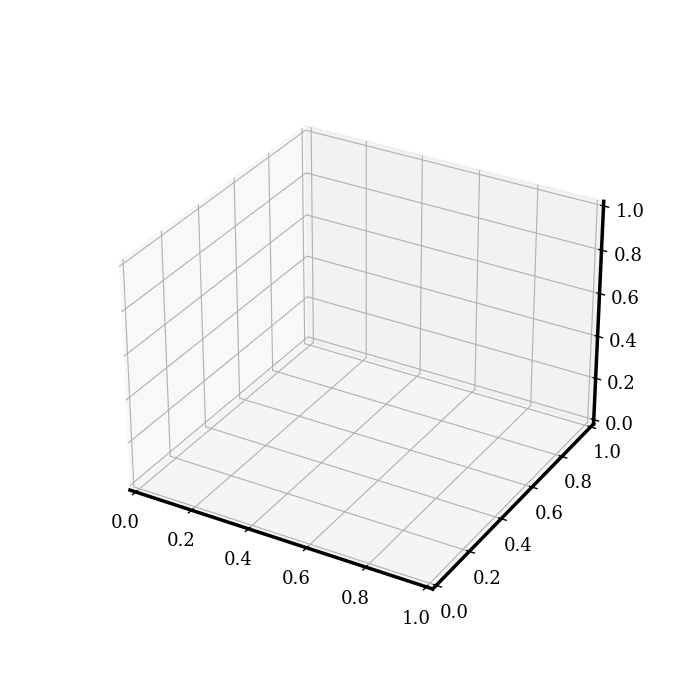

In [17]:
### exemple of dust in line of sights of different angular resolution

from nenupy.instru.interferometer import ObservingMode# visualising dust in different beams
figdust = plt.figure(figsize=(7,7))
# mosaicdust = figdust.subplot_mosaic('''
#                                 AA
#                                 BB
#                                 BB
#                                 ''')

# axlos = mosaicdust["A"]
# axmap0 = mosaicdust["B"]
ax = figdust.add_subplot(projection='3d')


In [19]:
colors = ["blue","green","orange","red"]
r_tau = 2000

xc,yc,zc = gal_to_cartesian(r_tau,*off_1,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="blue",ls='dotted')


xc,yc,zc = gal_to_cartesian(r_tau,*off_2,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="green",ls='dotted')

# xc,yc,zc = gal_to_cartesian(r_tau,*off_3,*off_3)
# ax.plot([0,xc],[0,yc],[0,zc], c="orange",ls='dotted')

# xc,yc,zc = gal_to_cartesian(r_tau,*off_4,*off_3)
# ax.plot([0,xc],[0,yc],[0,zc], c="red",ls='dotted')

xc,yc,zc = gal_to_cartesian(r_tau,taua_l.value,taua_b.value,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="red",ls='dotted')


In [20]:
xc,yc,zc = gal_to_cartesian(r_tau,taua_l.value,taua_b.value,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="red",ls='dashed')


In [21]:
ax.set_box_aspect(((x.max() - x.min())/3, y.max() - y.min(), z.max() - z.min()))


NameError: name 'x' is not defined

In [ ]:

# =========================
# CHOIX DU SEUIL
# =========================

positive_values = values[values > 0]

if positive_values.size == 0:
    raise ValueError("Aucune valeur strictement positive dans le cube.")

threshold = np.max(values)/20 #np.percentile(positive_values, 90)
print(f"Seuil utilisé : {threshold:.5g}")

# =========================
# EXTRACTION DE L'ISOSURFACE
# =========================

verts, faces, normals, vals = measure.marching_cubes(
    values,
    level=threshold,
    spacing=(dx, dy, dz)
)

# décalage pour remettre l'origine physique correcte
verts[:, 0] += x0
verts[:, 1] += y0
verts[:, 2] += z0

# =========================
# AFFICHAGE 3D MATPLOTLIB
# =========================

# fig = plt.figure(figsize=(9, 7))
# ax = fig.add_subplot(111, projection="3d")
ax.clear()
mesh = Poly3DCollection(
    verts[faces],
    alpha=0.4,
    linewidths=0.05,
    color='gray'
)
ax.add_collection3d(mesh)
############################################################################"
threshold = np.max(values)/100 #np.percentile(positive_values, 90)
print(f"Seuil utilisé : {threshold:.5g}")

# =========================
# EXTRACTION DE L'ISOSURFACE
# =========================

verts, faces, normals, vals = measure.marching_cubes(
    values,
    level=threshold,
    spacing=(dx, dy, dz)
)

# décalage pour remettre l'origine physique correcte
verts[:, 0] += x0
verts[:, 1] += y0
verts[:, 2] += z0

# =========================
# AFFICHAGE 3D MATPLOTLIB
# =========================

# fig = plt.figure(figsize=(9, 7))
# ax = fig.add_subplot(111, projection="3d")
# ax.clear()
mesh = Poly3DCollection(
    verts[faces],
    alpha=0.4,
    linewidths=0.05,
    color='lightgray'
)
ax.add_collection3d(mesh)


# limites physiques
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_zlim(z.min(), z.max())

# ax.set_xlabel("Radius (pc)")
# ax.set_ylabel("Y (pc)")
# ax.set_zlabel("Z (pc)")
# ax.set_title(f"Dust clouds in the line-of-sights towards Taurus A")

ax.set_yticklabels([])
ax.set_zticklabels([])
# figdust.tight_layout()

xc,yc,zc = gal_to_cartesian(r_tau,*off_1,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="blue",ls='dotted')


xc,yc,zc = gal_to_cartesian(r_tau,*off_2,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="green",ls='dotted')

# xc,yc,zc = gal_to_cartesian(r_tau,*off_3,*off_3)
# ax.plot([0,xc],[0,yc],[0,zc], c="orange",ls='dotted')

# xc,yc,zc = gal_to_cartesian(r_tau,*off_4,*off_3)
# ax.plot([0,xc],[0,yc],[0,zc], c="red",ls='dotted')

xc,yc,zc = gal_to_cartesian(r_tau,taua_l.value,taua_b.value,*off_3)
ax.plot([0,xc],[0,yc],[0,zc], c="black",ls='dashed')

ax.set_xlabel("")


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figdust.savefig("dust3D-noHI.png", bbox_inches='tight')
plt.close(figdust)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
np.max(values)/100


In [ ]:
figfov = plt.figure()


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
(len(Xnonan)- len(X.flatten()))/len(X.flatten())


In [ ]:
# Initialisation explicite de la carte de poussière si nécessaire.
maps.init_dustmap()


## Profils d'extinction et champs de vue


In [ ]:
# LonTAUA, LatTAUA = maps.get_axes(CoordTaua,fov,delta)
# EXTINTAUAS = []
radii = np.arange(0.03,2,0.05)
# for k in range(len(radii)-1):
#     EXTINTAUAS.append(maps.get_EXTIN_fov(CoordTaua, fov, delta, radiusmin = radii[k], radiusmax=radii[k+1]))

# EXTINTAUATOT = maps.get_EXTIN_fov(CoordTaua, fov, delta)

EXTINTAUA_los = maps.DustMap().extinction_los(Coord, fov, delta)
radiitot = np.arange(0.03,2,0.01)


In [ ]:
# Frequencies = [79.11, 69.16,60.81, 53.76,47.75,42.61,38.18,34.34,31,27.41,23.79,20.79,18.27,16.14,14.33,12.78]
Frequencies = [10,20,50,85]
mas_to_use = [f"MA00{i}" for i in range(10)] + [f'MA0{i}' for i in range(10,80)]
nenufar_core = NenuFAR()[mas_to_use]
dNenu = nenufar_core.angular_resolution(frequency=Frequencies*u.MHz).value


In [ ]:
Coord = Coordoff3
if 'dustfov' in globals().keys():
    pass
else :
    dustfov = maps.get_EXTIN_fov(Coord, fov, delta)

l,b = taua_l.value, taua_b.value

m0 = axmap0.imshow(dustfov, extent=(l-fov[0].value/2, l+fov[0].value/2, b-fov[1].value/2, b+fov[0].value/2), origin = 'lower')
# m1 = axmap1.imshow(mom1_fullsp, extent=(l-fov[0].value/2, l+fov[0].value/2, b-fov[1].value/2, b+fov[0].value/2), origin = 'lower', cmap='rainbow')
# plt.colorbar(mappable=m1,cax = map1cbar)

# axlos.plot(radiitot,EXTINTAUA_los, c="k")

# axmap0.plot(taua_l,taua_b,"*",c='w',ms=10)
# axmap1.plot(taua_l,taua_b,"*",c='w',ms=10)

for exten in dNenu[::-1] :
    los = maps.DustMap().extinction_los(Coord, (exten*u.deg,exten*u.deg),delta)
    axlos.plot(radiitot,los)
    circle = exten/2 * np.cos(theta)+l,exten/2 * np.sin(theta) + b
    axmap0.plot(*circle,'--')


In [ ]:
dustlos= maps.DustMap().extinction_los(Coord, fov, delta)
dustfov = maps.get_EXTIN_fov(Coord, fov, delta)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
delta


In [ ]:
### faire vue du dessus ou vue 3D ?

figdust = plt.figure()
axdust = figdust.add_subplot()


In [ ]:
axdust.clear()
axdust.plot(dustlos)


## Cube CO : extraction, moments et comparaison aux faisceaux


## CO Cube


In [ ]:
# Chargement / préparation des données CO.
# path = "COmaps/"
# print(os.listdir(path))

# HDU_CO = fits.open(path+os.listdir(path)[-2])[0]

maps.init_PPVmaps(path_CO = '../../Notebooks/COmaps/',path_HI = '../../Notebooks/HImaps/')


In [ ]:
tracer = 'CO'
fov = (10*u.deg,10*u.deg)
Coord = Coordoff3
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = maps.crop_map_square(Coord,tracer, fov)

pixdim = SLICECO.shape


In [ ]:
SLICECOnonan = np.copy(SLICECO)
SLICECOnonan[np.isnan(SLICECO)] = 1e-16
SLICECOnonan[SLICECOnonan<1.1] = 1e-16
mom1 = np.sum(SLICECOnonan*velCO, axis=2)/np.sum(SLICECOnonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
mom1[mom1==4.227500127788173] = np.nan
mom1CO = np.copy(mom1)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
(SLICECOnonan*velCO).shape, SLICECOnonan.shape, velCO.shape


In [ ]:
### exemple of CO in different nenufar beams

figCO = plt.figure(figsize=(7,15))
# mosaicCO = figCO.subplot_mosaic('''
#                                 bb.cde
#                                 BB.cde
#                                 BB.fgh
#                                 BB.ijk
#                                 BB.ijk
#                                 ''', width_ratios=(3,3,.5,2,2,2), height_ratios=(1,10,11,10,1))
mosaicCO = figCO.subplot_mosaic('''
                                A
                                B
                                ''')#,height_ratios = (0.5,10,3,0.5,10))

# axmap0 = figCO.add_axes([0.15, 0.1, 0.7, 0.3])
# map0cbar = figCO.add_axes([0.15, 0.4, 0.7, 0.02])
#
# axmap1 = figCO.add_axes([0.15, 0.1+.5, 0.7, 0.3])
# map1cbar = figCO.add_axes([0.15, 0.4+.5, 0.7, 0.02])

# axmap0 = mosaic["A"]
# # axmap1 = mosaicHI["C"]
# # map0cbar = mosaic["a"]
# div0 = make_axes_locatable(axmap0)
# map0cbar = div0.append_axes('top',size='5%',pad=0.05)

# axmap1 = mosaic["B"]
# # axmap1 = mosaicHI["C"]
# # map1cbar = mosaic["b"]
# div1 = make_axes_locatable(axmap1)
# map1cbar = div1.append_axes('top',size='5%',pad=0.05)


In [ ]:
# dust fov
da_dust_fov = da_dust.sum(dim='x')[:,:,0]


In [ ]:
plt.colorbar(imgdust, label="$A_{dust}$")


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')


velos = []
extens =2.1
tracer = 'CO'
mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["A"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()

axmap1 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map1cbar = mosaic["b"]
div1 = make_axes_locatable(axmap1)
map1cbar = div1.append_axes('top',size='5%',pad=0.05)

axmap1.clear()
map1cbar.clear()
# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('$T_b$ (K)', size=15)

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
m1 = axmap1.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='rainbow', vmin=0,vmax=10)
graphics.set_axes(axmap1, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m1,cax = map1cbar, location='top')
map1cbar.set_title('Velocity (km/s)', size=15)

# axmap0.plot(center_l.value,center_b.value,".",c='black',ms=10)

velos = []
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

imgdust = axmap0.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)
axmap1.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)
axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)

axmap1.set_xlabel("Galactic Longitude", size=15)
axmap1.set_ylabel("Galactic Latitude", size=15)
# figtracer.supxlabel("Velocity (km/s)", size=16, x=0.72, y=0.01)
# figtracer.supylabel('$T_b$ (K)', size=16, x=0.91, y=0.5,rotation=270)
# figHI.tight_layout()
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)
# figHI.tight_layout()
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figCO.tight_layout()
# figCO.savefig('CO-moments.pdf')


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figCO.savefig('CO-moments.pdf')


In [ ]:
## DEUXIEME FIG : consecutive beams
### exemple of CO in different nenufar beams

figCO2 = plt.figure(figsize=(6,12))
mosaicCO = figCO2.subplot_mosaic('''
                                BBB
                                ...
                                cde
                                fgh
                                ijk
                                ''', height_ratios=(10,1.5,3,3,3))
# mosaicCO = figCO.subplot_mosaic('''

#                                 BB
#                                 ''')


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
tracer = 'CO'
fov = (5*u.deg,5*u.deg)
Coord = CoordTaua
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = maps.crop_map_square(Coord,tracer, fov)

pixdim = SLICECO.shape
velos = []
extens =5
tracer = 'CO'
mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()
# ============== POINTINGS ==========================
exten_max = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
axmap0.add_patch(taua_spatial_rep)
tracer = "CO"

# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('$T_b$ (K)', size=15)


for i in range(len(Frequencies)):
#     i = len(Frequencies)
    exten = dNenu[i]
    axspectrum = mosaic[alphabet[i+2]]
    axspectrum.clear()

#     for v in velos:

#         axspectrum.vlines(v,0, spect[np.nanargmin(np.abs(velHI-v))],color='k', linewidth =1)


#     circle = exten/2 * np.cos(theta)+l,exten/2 * np.sin(theta) + b
#     axmap0.plot(*circle,'--', color=colors[i])

        # we compare to the nenufar actual beam
    table = np.array(beam_[i].reshape((50, 50)) )
    # regridding
    X,Y = np.meshgrid(lonslice,latslice)
    #
    regrided_beam= RegularGridInterpolator(points=(lon[0],lat[:,0]),values=table, method="linear")((X,Y))

    SLICECO_test = np.copy(SLICECO)
    SLICECO_test[regrided_beam<np.max(regrided_beam)/2, :] = np.nan

    moment0 = np.nanmean(SLICECO_test, axis=2)
    moment0[moment0==0] = np.nan
    spectrum = np.nanmean(SLICECO_test, axis=(0,1))


    axspectrum.plot(vel,spectrum, c = colors[i])
    if exten>exten_max :
        axmap0.contour(table.T,levels=[np.max(table)/2], extent=(lon[0,0],lon[0,-1],lat[0,0],lat[-1,0]), colors = colors[i],linestyles=['dotted'])
    else :
        axmap0.contour(table.T,levels=[np.max(table)/2], extent=(lon[0,0],lon[0,-1],lat[0,0],lat[-1,0]), colors = colors[i])

#     axmap0.imshow(moment0,extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin="lower")

    # axmap0.text(l,-exten/2+b,f"{dNenu[i]:.2f}°",size=13,ha="center",va="top" ,color=colors[i]) #,transform=axmap0.transAxes)

    axspectrum.set_title(f'{1/Frequencies[i]:.1f} MHz\n{dNenu[i]:.2f}°', size=15, y=0.5, x=0.09,ha='left')
    graphics.set_axes(axspectrum,pad=7)
    axspectrum.set_xlim(-19,19)
    axspectrum.set_ylim(-0.01,0.9)
    axspectrum.set_yticklabels([])
    if i<6:
        axspectrum.set_xticklabels([])


axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

figCO2.supxlabel("Velocity (km/s)", size=16, x=0.5, y=0.05)
mosaicCO["f"].set_ylabel('$T_b$ (K)')#, size=16, x=0.91, y=0.5)#,rotation=270)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figCO2.tight_layout()
figCO2.subplots_adjust(wspace=0, hspace=0)

figCO2.savefig('CO-beams.pdf')


In [ ]:
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)
figCO2.supxlabel("Velocity (km/s)", size=14, x=0.5, y=0.03)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figCO2.tight_layout()
figCO2.subplots_adjust(wspace=0, hspace=0)
figCO2.savefig('CO-beams.pdf')


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
np.max(latslice), np.max(lat)


## Cube HI : extraction, moments et comparaison aux faisceaux


## HI


In [ ]:
# Chargement / préparation des données HI.
tracer = 'HI'
fov = (10*u.deg,10*u.deg)
# Coord = Coordoff3
Coord = CoordTaua
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)
pixdim = SLICEHI.shape


In [ ]:
# maxi = np.nanmax(SLICEHInonan)
SLICEHInonan = np.copy(SLICEHI).T
SLICEHInonan[np.isnan(SLICEHI).T] = 0
maxi = np.nanmax(SLICEHInonan)
SLICEHInonan[SLICEHInonan<0.1*maxi] = 0
mom1 = np.nanmean(SLICEHInonan*velHI, axis=2) /np.nanmean(SLICEHInonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICEHInonan*velHI, axis=2, weights=SLICEHInonan)
# mom1[mom1==4.227500127788173] = np.nan
mom1HI = np.copy(mom1)


In [ ]:
tracer = 'HI'
fov = (3*u.deg,3*u.deg)
Coord = Coordoff3
vmin_HI = -50
vmax_HI = -30
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.cropped_mom0(Coord,tracer, fov,vmin_HI,vmax_HI, shape="square")


In [ ]:
axmap0.clear()
axmap0.plot(velHI,spectrumHI)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
SLICEHInonan.max()


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
mom1


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
velHI[1]-velHI[0]


In [ ]:
### exemple of CO in different nenufar beams

figHI = plt.figure(figsize=(10,5))
# mosaicCO = figCO.subplot_mosaic('''
#                                 bb.cde
#                                 BB.cde
#                                 BB.fgh
#                                 BB.ijk
#                                 BB.ijk
#                                 ''', width_ratios=(3,3,.5,2,2,2), height_ratios=(1,10,11,10,1))
# mosaicHI = figHI.subplot_mosaic('''
#                                 A
#                                 B
#                                 ''')#, height_ratios = (0.5,10))

mosaicHI = figHI.subplot_mosaic('''
                                AB
                                AC
                                ''')#,height_ratios=(3,5))

axmap1 = mosaicHI["A"]
axmap0 = mosaicHI["B"]
axmap2 = mosaicHI["C"]

# axes = figHI.subplots(3,2)


In [ ]:
radiusmin = 0.1
radiusmax = 0.3
# radiusmax = 1.7
vmin_HI = 0
vmax_HI = 10
pct = 0.50

radius = np.arange(radiusmin,radiusmax,0.005)
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
fov05 = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value/2
fov = (fov05*u.deg,fov05*u.deg)

dustlos= maps.DustMap().extinction_los(Coord, fov, delta)
dustfov = maps.get_EXTIN_fov(Coord, fov, delta)
Coord = Coordoff1
dustlos_cut = maps.DustMap().extinction_los(Coord,fov,delta,radiusmin=radiusmin,radiusmax=radiusmax)
dustfov_cut = maps.get_EXTIN_fov(Coord,fov,delta,radiusmin=radiusmin,radiusmax=radiusmax)
axmap0.clear()
axmap1.clear()
axmap2.clear()
axmap0.plot(radiitot,dustlos,'k')
axmap0.plot(radius,dustlos_cut,'r')
# imgdust = axmap1.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)
# m1 = axmap1.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='jet',vmax=7)
# axmap1.contour(dustfov_cut,extent=(off_3[0]-fov05,off_3[0]+fov05,off_3[1]-fov05,off_3[1]+fov05),cmap='Greys',origin="lower",levels=15)

tracer = 'HI'
fovHI = (5*u.deg,5*u.deg)
Coord = Coordoff1

SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.cropped_mom0(Coord,tracer, fovHI,vmin_HI,vmax_HI, shape="square")

indmin = np.where(velHI>vmin_HI)[0][1]
indmax = np.where(velHI<vmax_HI)[0][-1]
SLICE_true = SLICEHI[indmin:indmax,:,:]

m0 = axmap1.imshow(np.nanmean(SLICE_true,axis=0), extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='Reds')

condv = (velHI<vmax_HI)*(velHI>vmin_HI)

axmap2.plot(velHI,spectrumHI,c='k')
axmap2.plot(velHI[condv],spectrumHI[condv],c='r')
# ### HI clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

extens = 2

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)

extinlosCO = np.copy(dustlos_cut)
EXTINTAUA_los = np.copy(dustlos)
EXTINTAUATOT = np.copy(dustfov)
EXTIN_k_CO = np.copy(dustfov_cut)

maxi = np.nanmax(extinlosCO)
maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)

# cond = (velCO>vmin_CO) * (velCO<vmax_CO)
# axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
# if dustCO :
exten = 2*fov05*u.deg
e1 = Coord.galactic.l.value - exten.value/2
e2 = Coord.galactic.l.value + exten.value/2
e3 = Coord.galactic.b.value - exten.value/2
e4 = Coord.galactic.b.value + exten.value/2
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
maxi_rel2 = np.nanmax(EXTIN_k_CO)/np.nanmax(EXTINTAUATOT)
maxi_rel3 =1# np.nanmax(EXTIN_k_CO)/np.nanmax(EXTINTAUATOT)
# axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
dustcontour = axmap1.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT), extent=(e1,e2,e3,e4),cmap='Greys',vmin=0.1*maxi_rel3,vmax=maxi_rel3)
dustcontour = axmap1.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT), extent=(e1,e2,e3,e4),levels=[pct*maxi_rel2],vmin=0.1*maxi_rel3,vmax=maxi_rel3,cmap='Greys',linestyles=['dashed'])


axmap0.hlines(pct*maxi,radiusmin, radiusmax,color="r")

fw90 = np.where(extinlosCO> pct*maxi)[0]
length = radius[fw90][-1] - radius[fw90][0]
if length == 0:
    length = 1*(radius[1]-radius[0])
axmap0.text(radiusmax*1.01, pct*maxi, f'fw{pct*100:.0f}% = {length*1e3 : .2f} pc', ha='left', va='center',fontsize=10)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
maps.DustMap().extinction_los


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
delta


In [ ]:
# maxi_rel = maxi/np.nanmax(EXTINTAUA_los)

# dustcontour = axmap0.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT)<, extent=(e1,e2,e3,e4),levels=np.sort([pct*maxi_rel,(pct-0.1)*maxi_rel,(pct-0.2)*maxi_rel]),cmap='Greys')


In [ ]:
# fov = (5*u.deg, 5*u.deg)
dustlos= maps.DustMap().extinction_los(Coord, fov, delta)
dustfov = maps.get_EXTIN_fov(Coord, fov, delta)


In [ ]:
# fw90 = np.where(extinlosCO/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
# length = radiitot[condCO][fw90][-1] - radiitot[condCO][fw90][0]
# axdust.text(radiusminCO, 1.1*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')

velos = []
extens =3
tracer = 'HI'
mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0.clear()
axmap1.clear()
# axmap0 = mosaicHI["A"]
# map0cbar = mosaic["a"]
# div0 = make_axes_locatable(axmap0)
# map0cbar = div0.append_axes('top',size='5%',pad=0.05)
# axmap0.clear()
# map0cbar.clear()

# axmap1 = mosaicHI["B"]
# axmap1 = mosaicHI["C"]
# map1cbar = mosaic["b"]
div1 = make_axes_locatable(axmap1)
map1cbar = div1.append_axes('top',size='5%',pad=0.05)

axmap1.clear()
map1cbar.clear()
# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
# axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Reds')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
# graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
# plt.colorbar(mappable=m0,cax = map0cbar, location='top')
# map0cbar.set_title('$T_b$ (K)', size=15)

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
m1 = axmap1.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='jet',vmax=7)
graphics.set_axes(axmap1, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m1,cax = map1cbar, location='top')
map1cbar.set_title('Velocity (km/s)', size=15)

# axmap0.plot(center_l.value,center_b.value,".",c='black',ms=10)

velos = []
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )


# axmap0.set_xlabel("Galactic Longitude", size=15)
# axmap0.set_ylabel("Galactic Latitude", size=15)

axmap1.set_xlabel("Galactic Longitude", size=15)
axmap1.set_ylabel("Galactic Latitude", size=15)
# figtracer.supxlabel("Velocity (km/s)", size=16, x=0.72, y=0.01)
# figtracer.supylabel('$T_b$ (K)', size=16, x=0.91, y=0.5,rotation=270)
# figHI.tight_layout()
Coord = Coordoff3
# extens=5
center_b = Coord.galactic.b
center_l = Coord.galactic.l
# axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
# axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)
# figHI.tight_layout()
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
# figCO.tight_layout()
# figCO.savefig('HI-moments.pdf')


In [ ]:
# ax.clear()
# ax.axis('off')
for ax in axes.flatten():
    graphics.set_axes(ax,pad=5)
figHI.supylabel("Galactic latitude")
figHI.supxlabel("Galactic longitude",y=0.05)
# figHI.savefig('slices_HI.pdf')


In [ ]:
axmap0 = axes.flatten()[5]
tracer = 'HI'
fov = (6*u.deg,6*u.deg)
extens=3
Coord = Coordoff3
# vmin_HI+=
vmin_HI = 10
vmax_HI = 20


radiusmin=0.03
radiusmax = 0.25
SLICEHI,velHI, spectrumHI, lonslice, latslice, mom0 = maps.cropped_mom0(Coord,tracer, fov,vmin_HI,vmax_HI, shape="square")
cond = (velHI<=vmax_HI) * (velHI>=vmin_HI)
# axmap1.clear()
# axmap1.plot(velHI,spectrumHI,c='k')
# axmap1.fill_between(velHI[cond],spectrumHI[cond],color='r')

axmap0.clear()
axmap0.imshow(mom0, origin='lower', extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]),cmap='Reds',vmax=3,vmin=0)
axmap0.set_title(f"{vmin_HI} to {vmax_HI} km/s")

# axmap2.clear()
# axmap2.plot(radiifull,dustlos_full,color='k')

# dustlos_cut = maps.DustMap().extinction_los(Coord,fov,delta,radiusmin=radiusmin,radiusmax=radiusmax)
# radiicut = np.arange(radiusmin,radiusmax,0.01)
# axmap2.fill_between(radiicut,dustlos_cut,color='k')
# axmap0.contour(dustfov_cut,extent=(off_3[0]-fov[0].value/2,off_3[0]+fov[0].value/2,off_3[1]-fov[0].value/2,off_3[1]+fov[0].value/2),cmap='Greys',origin="lower",levels=15)


Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
vel


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
dustlos_cut


In [ ]:
dustlos_full = maps.DustMap().extinction_los(Coord,fov,delta)
radiifull = np.arange(0.03,2,0.01)*u.kpc


In [ ]:
radiifull = np.arange(0.03,2,0.01)*u.kpc


In [ ]:
axmap1.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figHI.tight_layout()
figHI.savefig('HI-moments.pdf')


## Superposition HI/CO et diagnostics complémentaires


In [ ]:
SLICECOnonan = np.copy(SLICECO)
SLICECOnonan[np.isnan(SLICECO)] = 1e-16
SLICECOnonan[SLICECOnonan<1.1] = 1e-16
mom1CO = np.sum(SLICECOnonan*velCO, axis=2)/np.sum(SLICECOnonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
# mom1CO[mom1CO==4.227500127788173] = np.nan
axmap0.imshow(mom1CO, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='rainbow')#,levels=[3,8])


In [ ]:
axmap0.clear()


In [ ]:
cont = axmap0.contour(mom1CO, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap ='jet',levels=np.arange(10),vmin=0, vmax=10)#, colors=['k'])
axmap0.clabel(cont, levels=(2,6))


In [ ]:
# Cellule convertie depuis le format raw : code conservé pour exécution éventuelle.
axmap0.contour(mask, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',levels=[0.9], colors=['k'])


In [ ]:
mask = np.array(~np.isnan(mom1CO),dtype=int)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
mom0_fullsp_HI.shape, mom1.shape


In [ ]:
## DEUXIEME FIG : consecutive beams
### exemple of CO in different nenufar beams

figHI2 = plt.figure(figsize=(6,12))
mosaicHI = figHI2.subplot_mosaic('''
                                BBB
                                ...
                                cde
                                fgh
                                ijk
                                ''', height_ratios=(10,1.5,3,3,3))
# mosaicCO = figCO.subplot_mosaic('''

#                                 BB
#                                 ''')


In [ ]:
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)
figHI2.supxlabel("Velocity (km/s)", size=14, x=0.5, y=0.03)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figHI2.tight_layout()
figHI2.subplots_adjust(wspace=0, hspace=0)
figHI2.savefig('HI-beams.pdf')


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
mom0_fullsp_HI


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
tracer = 'HI'
fov = (5*u.deg,5*u.deg)
# Coord = Coordoff3
Coord = CoordTaua
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)
pixdim = SLICEHI.shape
velos = []
extens =4

mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}2")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()
# ============== POINTINGS ==========================
exten_max = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
axmap0.add_patch(taua_spatial_rep)
tracer = "HI"

# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Reds')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('$T_b$ (K)', size=15)


for i in range(len(Frequencies)):
#     i = len(Frequencies)
    exten = dNenu[i]
    axspectrum = mosaicHI[alphabet[i+2]]
    axspectrum.clear()

#     for v in velos:

#         axspectrum.vlines(v,0, spect[np.nanargmin(np.abs(velHI-v))],color='k', linewidth =1)


#     circle = exten/2 * np.cos(theta)+l,exten/2 * np.sin(theta) + b
#     axmap0.plot(*circle,'--', color=colors[i])

        # we compare to the nenufar actual beam
    table = np.array(beam_[i].reshape((50, 50)) )
    # regridding
    X,Y = np.meshgrid(lonslice,latslice)
    #
    regrided_beam= RegularGridInterpolator(points=(lon[0],lat[:,0]),values=table, method="linear")((X,Y))

    SLICEHI_test = np.copy(SLICEHI)
    SLICEHI_test[:,regrided_beam<np.max(regrided_beam)/2] = np.nan

    moment0 = np.nanmean(SLICEHI_test, axis=2)
    moment0[moment0==0] = np.nan
    spectrum = np.nanmean(SLICEHI_test, axis=(2,1))


    axspectrum.plot(vel,spectrum, c = colors[i])
    if exten>exten_max :
        axmap0.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i],linestyles=['dotted'])
    else :
        axmap0.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])

#     axmap0.imshow(moment0,extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin="lower")

    # axmap0.text(l,-exten/2+b,f"{dNenu[i]:.2f}°",size=13,ha="center",va="top" ,color=colors[i]) #,transform=axmap0.transAxes)

    axspectrum.set_title(f'{1/Frequencies[i]:.1f} MHz\n{dNenu[i]:.2f}°', size=15, y=0.5, x=0.09,ha='left')
    graphics.set_axes(axspectrum,pad=7)
    axspectrum.set_xlim(-69,69)
    axspectrum.set_ylim(-5,140)
    axspectrum.set_yticklabels([])
    if i<6:
        axspectrum.set_xticklabels([])


axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

figHI2.supxlabel("Velocity (km/s)", size=16, x=0.5, y=0.05)
mosaicHI["f"].set_ylabel('$T_b$ (K)')#, size=16, x=0.91, y=0.5)#,rotation=270)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figHI2.tight_layout()
figHI2.subplots_adjust(wspace=0, hspace=0)

# figHI2.savefig('HI-beams.pdf')


## Comparaison conjointe des spectres intégrés


In [ ]:
## recalcul :
tracer = 'CO'
fov = (10*u.deg,10*u.deg)
Coord = Coordoff3
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = maps.crop_map_square(Coord,tracer, fov)


SLICECOnonan = np.copy(SLICECO)
SLICECOnonan[np.isnan(SLICECO)] = 1e-16
SLICECOnonan[SLICECOnonan<1.1] = 1e-16
mom1 = np.sum(SLICECOnonan*velCO, axis=2)/np.sum(SLICECOnonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
mom1[mom1==4.227500127788173] = np.nan
mom1CO = np.copy(mom1)

##############################################
tracer = 'HI'
fov = (10*u.deg,10*u.deg)
# Coord = Coordoff3
Coord = Coordoff3
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)
pixdim = SLICEHI.shape
# maxi = np.nanmax(SLICEHInonan)
SLICEHInonan = np.copy(SLICEHI).T
SLICEHInonan[np.isnan(SLICEHI).T] = 0
maxi = np.nanmax(SLICEHInonan)
SLICEHInonan[SLICEHInonan<0.1*maxi] = 0
mom1 = np.nanmean(SLICEHInonan*velHI, axis=2) /np.nanmean(SLICEHInonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICEHInonan*velHI, axis=2, weights=SLICEHInonan)
# mom1[mom1==4.227500127788173] = np.nan
mom1HI = np.copy(mom1)


In [ ]:
### exemple of CO in different nenufar beams

figboth = plt.figure(figsize=(14,15))
# mosaicCO = figCO.subplot_mosaic('''
#                                 bb.cde
#                                 BB.cde
#                                 BB.fgh
#                                 BB.ijk
#                                 BB.ijk
#                                 ''', width_ratios=(3,3,.5,2,2,2), height_ratios=(1,10,11,10,1))
# mosaic = figboth.subplot_mosaic('''
#                                 Ac
#                                 Ad
#                                 Ae
#                                 Af
#                                 Bg
#                                 Bh
#                                 Bi
#                                 Bj
#                                 ''')
mosaic = figboth.subplot_mosaic('''
                                Ac
                                Bd
                                ''')


In [ ]:
mosaic['c'].set_title("Integrated HI spectrum", x=0.05,y=0.92,ha='left')
mosaic['d'].set_title("Integrated CO spectrum", x=0.05,y=0.92,ha='left')


In [ ]:
k=4
axis = mosaic["d"]
Coord = eval(f"Coordoff{k}")
# axis = mosaic["c"]
graphics.set_axes(axis,pad=5)
axis.clear()
tracer = 'HI'
_,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
arrow = {'width':1, "color":colors[k-1]}
axis.plot(velHI,spectrumHI,color=colors[k-1])

cond = np.abs(velHI-8)<1
# indexes = find_peaks(spectrumHI[cond],prominence=1e-10)[0]
# axis.plot(velHI[cond][indexes],spectrumHI[cond][indexes],'x')
axis.plot(velHI[cond],spectrumHI[cond],'x')
axis.set_xlim(-29,-20)
axis.set_ylim(-5,20)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
cond = np.abs(velHI+24)<1
velHI[cond], spectrumHI[cond]


In [ ]:
k=3
Coord = eval(f"Coordoff{k}")
axis = mosaic["c"]
graphics.set_axes(axis,pad=5)
axis.clear()
tracer = 'HI'
_,velHI, spectrumHI3, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)


In [ ]:
k=4
Coord = eval(f"Coordoff{k}")
axis = mosaic["c"]
graphics.set_axes(axis,pad=5)
axis.clear()
tracer = 'HI'
_,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
arrow = {'width':1, "color":colors[k-1]}
axis.plot(velHI,spectrumHI,color=colors[k-1])

cond = (velHI<40) & (velHI>-40)
indexes = find_peaks(spectrumHI[cond])[0]
for km in indexes :
    xm,ym = (velHI[cond][km],spectrumHI[cond][km])
    print(xm,ym)
    axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm-150,-50),textcoords="offset pixels",color=colors[k-1], arrowprops=arrow)
if k==3 :
    cond = np.abs(velHI-8)<1
    xm,ym = velHI[cond][0], spectrumHI[cond][0]
    axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-150,-50),textcoords="offset pixels",color=colors[k-1], arrowprops=arrow)
if k==4:
    cond = np.abs(velHI+24)<1
    xm,ym = velHI[cond][0], spectrumHI[cond][0]
    axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-150,-50),textcoords="offset pixels",color=colors[k-1], arrowprops=arrow)
axis.set_xlim(-49,43)
axis.set_ylim(-5,120)
axis.set_ylabel("$T_b$ (K)")
axis.set_xlabel("Velocity (km/s)")


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figboth.tight_layout()


In [ ]:
mosaic["c"].clear()
mosaic["d"].clear()
for k in range(1,5):
# for k in [1]:

    Coord = eval(f"Coordoff{k}")
    axis = mosaic["c"]
    graphics.set_axes(axis,pad=5)

    tracer = 'HI'
    _,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
    arrow = {'width':1, "color":colors[k-1],'headwidth':5,'headlength':5}
    axis.plot(velHI,spectrumHI,color=colors[k-1])

    cond = (velHI<40) & (velHI>-40)
    indexes = find_peaks(spectrumHI[cond])[0]
    kkm = -1.7
    for km in indexes :
        xm,ym = (velHI[cond][km],spectrumHI[cond][km])
        # print(xm,ym)
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*(20 - (k!=2)*(kkm<=-1.5)*50),ym-(kkm<=-1.5)*(k==3)*kkm*5-((kkm>-1.5)*k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        print((2*(k%2==0)-1)*20)
        kkm+=1.3
    if k==3 :
        cond = np.abs(velHI-8)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*20,ym-(k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    if k==4:
        cond = np.abs(velHI+24)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*23,ym),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    axis.set_xlim(-49,43)
    axis.set_ylim(-5,120)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")
    # axis = mosaic[alphabet[k+5]]
    axis = mosaic["d"]
    graphics.set_axes(axis,pad=5)
    # axis.clear()
    tracer = 'CO'
    _,velCO, spectrumCO, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)

    xm,ym = (velCO[np.nanargmax(spectrumCO)],np.nanmax(spectrumCO))
    axis.plot(velCO,spectrumCO,color=colors[k-1])
    # arrow = {'width':1, "color":colors[k-1]}
    if k<4 :
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-10,ym),color=colors[k-1], arrowprops=arrow)
    axis.set_xlim(-19,19)
    axis.set_ylim(-0.01,2.1)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figboth.savefig('newbeams.pdf')


## Pointages Nguyen et visualisations associées


In [ ]:
## nguyen pointings
Coordng1 = SkyCoord(l=186.76*u.deg, b=-7.11*u.deg, frame='galactic')
center_b = Coordng1.galactic.b
center_l = Coordng1.galactic.l
axmap0.plot(center_l.value,center_b.value,"x",c="k",ms=15)


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')

velos = []
extens =2.1
tracer = 'HI'
# mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
# lonslice = eval(f"lonslice_{tracer}")
# latslice = eval(f"latslice_{tracer}")
#mosaic = eval(f"mosaic{tracer}")
# vel = eval(f"vel{tracer}")
#figtracer = eval(f"fig{tracer}")
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
# Frequencies = np.linspace(1/85,0.1,9)
# dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["A"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()

axmap1 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map1cbar = mosaic["b"]
div1 = make_axes_locatable(axmap1)
map1cbar = div1.append_axes('top',size='5%',pad=0.05)

axmap1.clear()
map1cbar.clear()

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Reds')
m0 = axmap0.imshow(mom1HI, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='jet')#, vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('Velocity (km/s)', size=15)

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
m1 = axmap1.imshow(mom1CO, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='rainbow',vmin=0,vmax=10)
graphics.set_axes(axmap1, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m1,cax = map1cbar, location='top')
map1cbar.set_title('Velocity (km/s)', size=15)


# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
### CO clouds - on
k=1
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
k = 2
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)


### HI clouds - on
k=3
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
k=4
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================

# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - on
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================

# ax1 =
colors = ["blue","green","orange","red"]
k = 1
mosaic["c"].clear()
mosaic["d"].clear()
for k in range(1,5):
# for k in [1]:

    Coord = eval(f"Coordoff{k}")
    axis = mosaic["c"]
    graphics.set_axes(axis,pad=5)

    tracer = 'HI'
    _,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
    arrow = {'width':1, "color":colors[k-1],'headwidth':5,'headlength':5}
    axis.plot(velHI,spectrumHI,color=colors[k-1])

    cond = (velHI<40) & (velHI>-40)
    indexes = find_peaks(spectrumHI[cond])[0]
    kkm = -1.7
    for km in indexes :
        xm,ym = (velHI[cond][km],spectrumHI[cond][km])
        # print(xm,ym)
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*(20 - (k!=2)*(kkm<=-1.5)*50),ym-(kkm<=-1.5)*(k==3)*kkm*5-((kkm>-1.5)*k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        print((2*(k%2==0)-1)*20)
        kkm+=1.3
    if k==3 :
        cond = np.abs(velHI-8)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*20,ym-(k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    if k==4:
        cond = np.abs(velHI+24)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*23,ym),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    axis.set_xlim(-49,43)
    axis.set_ylim(-5,120)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")
    # axis = mosaic[alphabet[k+5]]
    axis = mosaic["d"]
    graphics.set_axes(axis,pad=5)
    # axis.clear()
    tracer = 'CO'
    _,velCO, spectrumCO, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)

    xm,ym = (velCO[np.nanargmax(spectrumCO)],np.nanmax(spectrumCO))
    axis.plot(velCO,spectrumCO,color=colors[k-1])
    # arrow = {'width':1, "color":colors[k-1]}
    if k<4 :
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-10,ym),color=colors[k-1], arrowprops=arrow)
    axis.set_xlim(-19,19)
    axis.set_ylim(-0.01,2.1)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")
for k in range(1,5):
    color = colors[k-1]

    Coord = eval(f"Coordoff{k}")
    center_b = Coord.galactic.b
    center_l = Coord.galactic.l
    axmap0.text(center_l.value,center_b.value, str(k), color=color,ha='left',va='bottom')
    axmap1.text(center_l.value,center_b.value, str(k), color=color,ha='left',va='bottom')
# axmap0.plot(center_l.value,center_b.value,".",c='black',ms=10)

velos = []
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )


axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)

axmap1.set_xlabel("Galactic Longitude", size=15)
axmap1.set_ylabel("Galactic Latitude", size=15)
# figtracer.supxlabel("Velocity (km/s)", size=16, x=0.72, y=0.01)
# figtracer.supylabel('$T_b$ (K)', size=16, x=0.91, y=0.5,rotation=270)
# figHI.tight_layout()
extens  = 3
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)


mosaic['c'].set_title("Integrated HI spectrum", x=0.05,y=0.9,ha='left')
mosaic['d'].set_title("Integrated CO spectrum", x=0.05,y=0.9,ha='left')
# figHI.tight_layout()
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
# figCO.tight_layout()
# figCO.savefig('HI-moments.pdf')
# figboth.savefig('newbeams.pdf')


In [ ]:
for k in range(4,5):
# for k in [1]:

    Coord = eval(f"Coordoff{k}")
    axis = mosaic["c"]
    graphics.set_axes(axis,pad=5)

    tracer = 'HI'
    _,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
    arrow = {'width':1, "color":colors[k-1],'headwidth':5,'headlength':5}
    # axis.plot(velHI,spectrumHI,color=colors[k-1])

    cond = (velHI<40) & (velHI>-40)
    indexes = find_peaks(spectrumHI[cond])[0]
    kkm = -1.7
    for km in indexes :
        xm,ym = (velHI[cond][km],spectrumHI[cond][km])
        # print(xm,ym)
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*(20 - (k!=2)*(kkm<=-1.5)*50),ym-(kkm<=-1.5)*(k==3)*kkm*5-((kkm>-1.5)*k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        print((2*(k%2==0)-1)*20)
        kkm+=1.3
        print(ym,xm)

    if k==4:
        cond = np.abs(velHI+24)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        # axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*23,ym),color=colors[k-1], arrowprops=arrow)
        kkm+=1
        print(ym,xm)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
84.31257/7.573106


## Cartes de vitesse et spectres par faisceau


In [ ]:
figspec = plt.figure(figsize=(9,15))
axss = figspec.subplot_mosaic('''
                              aa
                              AA
                              BB
                              ''', height_ratios=(0.5,10,3))

axcolo = axss['a']
axmap = axss['A']
ax1 = axss['B']
# ax2 = axss['C']
# ax3 = axss['D']
# ax4 = axss['E']


In [ ]:
## extracting spectra only in the fov of beams
axmap.clear()
axcolo.clear()
tracer = 'HI'

fov = (6*u.deg,6*u.deg)
Coord = Coordoff3
vmin_HI = -100
vmax_HI = 100
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)

SLICEHInonan = np.copy(SLICEHI).T
SLICEHInonan[np.isnan(SLICEHI).T] = 0
maxi = np.nanmax(SLICEHInonan)
SLICEHInonan[SLICEHInonan<0.1*maxi] = 0
mom1 = np.nanmean(SLICEHInonan*velHI, axis=2) /np.nanmean(SLICEHInonan,axis=2)

cb = axmap.imshow(mom1, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='jet')
plt.colorbar(mappable=cb, cax = axcolo, orientation = 'horizontal')


# fov = (6*u.deg,6*u.deg) #FOV[k_fov]
f = 40.81
exten =nenufar_core.angular_resolution(frequency=f*u.MHz).value
fov = (nenufar_core.angular_resolution(frequency=f*u.MHz),nenufar_core.angular_resolution(frequency=f*u.MHz))
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(l,b,"*",c=color,ms=15)

### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - on
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

colors = ["blue","green","orange","red"]
k = 1
axis = eval(f"ax{k}")
axis.clear()
# for k in range(1,5):
for k in [1]:
    Coord = eval(f"Coordoff{k}")

    SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_circle(Coord,tracer, fov)
    axis.plot(velHI,spectrumHI,color=colors[k-1])

axmap.set_xlabel("Galactic Longitude", size=15)
axmap.set_ylabel("Galactic Latitude", size=15)
axcolo.set_title('Velocity (km/s)')
ax1.set_xlabel("Velocity (km/s)")
ax1.set_ylabel("Arbitrary unit")
figspec.tight_layout()


## Comparaison des détections CRRL


In [ ]:
### figure all detections comparison with CRRLs
figs = plt.figure(figsize = (10,10))
axxs = figs.subplots(4,4)


In [ ]:
Coord = Coordoff4
couleur= colors[4-1]
freqs = np.array([74.80745712, 57.72151191, 47.85767653, 42.69548056, 38.25001807,
       34.40105947, 31.05179326, 28.12367143, 25.552512  , 23.28552417,
       21.27901719, 19.49662129, 17.90789529, 16.48722887, 14.4182482 ])

k = 0
for i in range(len(freqs)):
    ax = axxs.flatten()[i]
    ax.clear()
    f = freqs[i]
    fov = (nenufar_core.angular_resolution(frequency=f*u.MHz),nenufar_core.angular_resolution(frequency=f*u.MHz))
    SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_circle(Coord,tracer, fov)
    ax.plot(velHI,spectrumHI,color=couleur)
    ax.set_xlim(-75,75)
    ax.set_ylim(-5,120)
    ax.text(0.05,0.9,f"{f: .2f} MHz", transform = ax.transAxes,fontsize=12)

axxs.flatten()[-1].axis('off')
figs.subplots_adjust(wspace=0,hspace=0)


In [ ]:
## extracting spectra only in the fov of beams
axmap.clear()
axcolo.clear()
tracer = 'CO'

fov = (6*u.deg,6*u.deg)
Coord = Coordoff3
vmin_HI = -100
vmax_HI = 100
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)

SLICEHInonan = np.copy(SLICEHI)
SLICEHInonan[np.isnan(SLICEHI)] = 1e-16
SLICEHInonan[SLICEHInonan<1.1] = 1e-16
mom1 = np.sum(SLICEHInonan*velHI, axis=2)/np.sum(SLICEHInonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
mom1[mom1==4.227500127788173] = np.nan

cb = axmap.imshow(mom1, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='jet')
plt.colorbar(mappable=cb, cax = axcolo, orientation = 'horizontal')


# fov = (6*u.deg,6*u.deg) #FOV[k_fov]
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(l,b,"*",c=color,ms=15)

### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - on
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

colors = ["blue","green","orange","red"]
k = 1
axis = eval(f"ax{k}")
axis.clear()
for k in range(1,5):
    Coord = eval(f"Coordoff{k}")

    SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_circle(Coord,tracer, fov)
    axis.plot(velHI,spectrumHI,color=colors[k-1])

axmap.set_xlabel("Galactic Longitude", size=15)
axmap.set_ylabel("Galactic Latitude", size=15)
axcolo.set_title('Velocity (km/s)')
ax1.set_xlabel("Velocity (km/s)")
ax1.set_ylabel("Arbitrary unit")


In [ ]:
figu = plt.figure(figsize=(10,5))
mosaic = figu.subplot_mosaic('''
                           DDAA
                           DDCC
                           ''')


## Sélection de combinaisons poussière / CO / HI


In [ ]:
# Paramétrage d'une combinaison poussière / gaz à afficher.
### selecting a combination
pct = 0.90
recalcul =False # if run for the first time, or if the fov changed, set to True
fbeam = 10 # in MHz. Frequency used to compute the field of view

# beammax = 0.6
# maxbeam=True # to display the maximal nenufar beam

exten = 6*u.deg # nenufar_core.angular_resolution(frequency=fbeam*u.MHz)
Coord=Coordoff3
# exten =
# exten = 0.6*u.deg # set the extension of the fov manually
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
if recalcul :
    LonTAUA, LatTAUA = maps.get_axes(Coord,fov,delta)

## en kpc
radiusminCO = 1.52
radiusmaxCO = 1.62


# radiusminHI = 0.3
# radiusmaxHI = 0.5

# en km/s
vmin_CO, vmax_CO = 0, 5
# vmin_HI, vmax_HI = -5, 8


vminHI = 0
vmaxHI = 1

## affichage des contours
dustCO = True
dustHI = False


#### generate the right maps
# tracer = 'HI'
# SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

# tracer = 'CO'
# SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_i_CO = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_CO,vmax_CO, shape="square")

mom0_i_CO[mom0_i_CO==0] = np.nan
# mom0_i_HI[mom0_i_HI==0] = np.nan


# mom0_i_HI[27:33,27:33] = np.nan
if recalcul :
    EXTINTAUATOT = maps.get_EXTIN_fov(Coord, (exten,exten),delta)
    EXTINTAUA_los= maps.DustMap().extinction_los(Coord, (exten,exten),delta)

if dustHI+dustCO>0 :

    if dustCO :
        EXTIN_k_CO = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminCO, radiusmax = radiusmaxCO)
    if dustHI :
        EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)

# EXTIN_k_CO = np.sum([EXTINTAUAS[kk] for kk in range(k_CO, k_CO+dk_CO)], axis=0)
# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# #####################################

axmapCO = mosaic["D"]
axmapCO.clear()
# axmapHI = mosaic["D"]
# axmapHI.clear()

condCO = (radiitot>radiusminCO) * (radiitot<radiusmaxCO)
# condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)

extinlosCO = np.copy(EXTINTAUA_los)[condCO]
maxi = np.nanmax(extinlosCO)
# maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
# Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)
e1 = Coord.galactic.l.value - exten.value/2
e2 = Coord.galactic.l.value + exten.value/2
e3 = Coord.galactic.b.value - exten.value/2
e4 = Coord.galactic.b.value + exten.value/2
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
if dustCO :

    dustcontour = axmapCO.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT), extent=(e1,e2,e3,e4),levels=np.sort([pct*maxi_rel,(pct-0.1)*maxi_rel,(pct-0.2)*maxi_rel]),cmap='Greys')


# ## display of taua spatial extension
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
# #axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
axmapCO.add_patch(taua_spatial_rep)
# # axmapCO.plot(taua_l,taua_b,"*",c='k',ms=15)

# ## display of nenufar beam : we need to compute it to the right frequency (this can be put inside a function)

# # Observation times
# dt = TimeDelta(7200, format="sec")
# # obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
# obs_times = Time(timestamps)
# # North Celestial Pole tracking

# targ = FixedTarget.from_name("Tau A")
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

# # Discrete sky grid
# extension = 5*u.deg

# lon,lat = np.meshgrid(
#     np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
#     np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
# )

# sky = Sky(
#     coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
#     time=obs_times,
#     frequency=fbeam*u.MHz,
#     polarization=np.array([Polarization.NW, Polarization.NE])
# )
# # Array definition
# ma = NenuFAR()

# # Beam simulation and plotting

# conf = NenuFAR_Configuration(
#         beamsquint_correction=True,
#         beamsquint_frequency=50*u.MHz
#     )
# beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)


# beami = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


# table = np.array(beami.reshape((50, 50)) )

# axmapCO.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])

axmapCO.set_xlabel("Galactic Longitude", size=15)
axmapCO.set_ylabel("Galactic Latitude", size=15)

## crop to what interests us
# axmapCO.set_xlim(lonslice_CO[0], lonslice_CO[-1])
# axmapCO.set_ylim(latslice_CO[0], latslice_CO[-1])


# #### dust
axdust = mosaic['C']
axdust.clear()


axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustCO :
    # graphics.colored_line(radiitot[condCO],extinlosCO/np.nanmax(EXTINTAUA_los),Anorm[condCO],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminCO,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxCO,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative\nabsorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)
graphics.set_axes(axdust, pad=5,xgraduation=5)

axCO = mosaic['A']
axCO.clear()
Tnorm = spectrumCO/np.nanmax(spectrumCO)
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
axCO.plot(velCO,spectrumCO/np.nanmax(spectrumCO), c='gray')
axCO.plot(velCO[cond],spectrumCO[cond]/np.max(spectrumCO), c="blue")
# graphics.colored_line(velCO[cond],spectrumCO[cond]/np.max(spectrumCO),Tnorm[cond],axCO,**{"cmap":"Blues"})
axCO.axvline(vmin_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.axvline(vmax_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.set_xlim(-20,30)
axCO.set_ylim(-0.1,1.1)
axCO.set_xlabel("Velocity (km/s)")
axCO.set_ylabel("Relative\nintensity")
axCO.set_title("CO spectrum averaged \n in the beam of NenuFAR")
graphics.set_axes(axCO, pad=5,xgraduation=5)

maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
axdust.hlines(pct*maxi_rel,radiusminCO, radiusmaxCO,color="r")

fw90 = np.where(extinlosCO/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
length = radiitot[condCO][fw90][-1] - radiitot[condCO][fw90][0]
axdust.text(radiusmaxCO*1.1, pct*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)

# if maxbeam:
#     circle = beammax/2 * np.cos(theta)+center_l.value,beammax/2 * np.sin(theta) + center_b.value
#     axmapCO.plot(*circle,'--',c="k",linewidth=1)
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)


# exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

bs = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapCO.plot(*circle,'--', c=color)
axmapCO.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapCO.plot(*circle,'--', c=color)
axmapCO.plot(center_l.value,center_b.value,".",c=color,ms=10)

figu.tight_layout()


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
maxi


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
exten


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
EXTIN_k_CO.shape


In [ ]:
# Paramétrage d'une combinaison poussière / gaz à afficher.
### selecting a combination
pct = 0.30
recalcul =False # if run for the first time, or if the fov changed, set to True
fbeam = 10 # in MHz. Frequency used to compute the field of view

# beammax = 0.6
# maxbeam=True # to display the maximal nenufar beam

exten = 6*u.deg # nenufar_core.angular_resolution(frequency=fbeam*u.MHz)
Coord=Coordoff3
# exten =
# exten = 0.6*u.deg # set the extension of the fov manually
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
if recalcul :
    LonTAUA, LatTAUA = maps.get_axes(Coord,fov,delta)

## en kpc
# radiusminHI = 1.5
# radiusmaxHI = 1.7

# radiusminHI = 0.1
# radiusmaxHI = 0.25

radiusminHI = 0.3
radiusmaxHI = 0.5

# en km/s
vmin_HI, vmax_HI = 5, 15
vmin_HI, vmax_HI = -5, 8


vminHI = 0
vmaxHI = 1

## affichage des contours
dustHI = False
dustCO = True


#### generate the right maps
tracer = 'HI'
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

# tracer = 'HI'
# SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

mom0_i_HI[mom0_i_HI==0] = np.nan
# mom0_i_HI[mom0_i_HI==0] = np.nan


# mom0_i_HI[27:33,27:33] = np.nan
if recalcul :
    EXTINTAUATOT = maps.get_EXTIN_fov(Coord, (exten,exten),delta)
    EXTINTAUA_los= maps.DustMap().extinction_los(Coord, (exten,exten),delta)

if dustHI+dustHI>0 :

    # if dustHI :
    #     EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)
    if dustHI :
        EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)

# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# #####################################

# axmapHI = mosaic["D"]
# axmapHI.clear()
axmapHI = mosaic["D"]
axmapHI.clear()

# condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)
condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)

extinlosHI = np.copy(EXTINTAUA_los)[condHI]
maxi = np.nanmax(extinlosHI)
maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)

cond = (velHI>vmin_HI) * (velHI<vmax_HI)
axmapHI.imshow(mom0_i_HI/np.sum(cond),vmin=0, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='Reds')
if dustHI :

    dustcontour = axmapHI.contour(LonTAUA,LatTAUA,EXTIN_k_HI/np.nanmax(EXTINTAUATOT), levels=[pct*maxi_rel],colors=['k'])#,cmap='Greys')


# ## display of taua spatial extension
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
# #axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
# # axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)

# ## display of nenufar beam : we need to compute it to the right frequency (this can be put inside a function)

# # Observation times
# dt = TimeDelta(7200, format="sec")
# # obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
# obs_times = Time(timestamps)
# # North Celestial Pole tracking

# targ = FixedTarget.from_name("Tau A")
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

# # Discrete sky grid
# extension = 5*u.deg

# lon,lat = np.meshgrid(
#     np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
#     np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
# )

# sky = Sky(
#     coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
#     time=obs_times,
#     frequency=fbeam*u.MHz,
#     polarization=np.array([Polarization.NW, Polarization.NE])
# )
# # Array definition
# ma = NenuFAR()

# # Beam simulation and plotting

# conf = NenuFAR_Configuration(
#         beamsquint_correction=True,
#         beamsquint_frequency=50*u.MHz
#     )
# beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)


# beami = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


# table = np.array(beami.reshape((50, 50)) )

# axmapHI.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])

axmapHI.set_xlabel("Galactic Longitude", size=15)
axmapHI.set_ylabel("Galactic Latitude", size=15)

## crop to what interests us
# axmapHI.set_xlim(lonslice_HI[0], lonslice_HI[-1])
# axmapHI.set_ylim(latslice_HI[0], latslice_HI[-1])


# #### dust
axdust = mosaic['C']
axdust.clear()


axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustHI :
    graphics.colored_line(radiitot[condHI],extinlosHI/np.nanmax(EXTINTAUA_los),Anorm[condHI],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminHI,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxHI,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative\nabsorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)
graphics.set_axes(axdust, pad=5,xgraduation=5)

axHI = mosaic['A']
axHI.clear()
Tnorm = spectrumHI/np.nanmax(spectrumHI)
cond = (velHI>vmin_HI) * (velHI<vmax_HI)
axHI.plot(velHI,spectrumHI/np.nanmax(spectrumHI), c='gray')
axHI.plot(velHI[cond],spectrumHI[cond]/np.max(spectrumHI), c="blue")
# graphics.colored_line(velHI[cond],spectrumHI[cond]/np.max(spectrumHI),Tnorm[cond],axHI,**{"cmap":"Blues"})
axHI.axvline(vmin_HI,0.05,0.95,color="blue",linestyle="dotted")
axHI.axvline(vmax_HI,0.05,0.95,color="blue",linestyle="dotted")
axHI.set_xlim(-20,30)
axHI.set_ylim(-0.1,1.1)
axHI.set_xlabel("Velocity (km/s)")
axHI.set_ylabel("Relative\nintensity")
axHI.set_title("HI spectrum averaged \n in the beam of NenuFAR")
graphics.set_axes(axHI, pad=5,xgraduation=5)

maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
axdust.hlines(pct*maxi_rel,radiusminHI, radiusmaxHI,color="r")

fw90 = np.where(extinlosHI/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
length = radiitot[condHI][fw90][-1] - radiitot[condHI][fw90][0]
axdust.text(radiusmaxHI*1.1, pct*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)

# if maxbeam:
#     circle = beammax/2 * np.cos(theta)+center_l.value,beammax/2 * np.sin(theta) + center_b.value
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)


# exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
# ### HI clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

bs = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### HI clouds - on
color = 'orange'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapHI.plot(*circle,'--', c=color)
axmapHI.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapHI.plot(*circle,'--', c=color)
axmapHI.plot(center_l.value,center_b.value,".",c=color,ms=10)

figu.tight_layout()


In [ ]:
# np.where(EXTIN_k_CO/np.nanmax(EXTINTAUATOT)>maxidust)


## Profil final d'extinction et mesure des largeurs de nuages


In [ ]:
axdust.clear()
axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustCO :
    graphics.colored_line(radiitot[condCO],extinlosCO/np.nanmax(EXTINTAUA_los),Anorm[condCO],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminCO,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxCO,0.05,0.95,color="black",linestyle="dotted")
if dustHI :
    graphics.colored_line(radiitot[condHI],extinlosHI/np.nanmax(EXTINTAUA_los),Anorm[condHI],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminHI,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxHI,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative absorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)

get_length_clouds(EXTINTAUA_los/np.nanmax(EXTINTAUA_los))


In [ ]:
# Paramétrage d'une combinaison poussière / gaz à afficher.
### selecting a combination
pct = 0.90
recalcul =False # if run for the first time, or if the fov changed, set to True
fbeam = 10 # in MHz. Frequency used to compute the field of view

# beammax = 0.6
# maxbeam=True # to display the maximal nenufar beam

exten = 5*u.deg # nenufar_core.angular_resolution(frequency=fbeam*u.MHz)
# exten = 0.6*u.deg # set the extension of the fov manually
if recalcul :
    LonTAUA, LatTAUA = maps.get_axes(Coord,(exten,exten),delta)

## en kpc
radiusminCO = 1.5
radiusmaxCO = 1.7

radiusminHI = 1.5
radiusmaxHI = 1.7

# en km/s
vmin_CO, vmax_CO = -5, 5
vmin_HI, vmax_HI = -5, 8


vminHI = 0
vmaxHI = 1

## affichage des contours
dustCO = False
dustHI = True


#### generate the right maps
tracer = 'HI'
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

tracer = 'CO'
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_i_CO = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_CO,vmax_CO, shape="square")

mom0_i_CO[mom0_i_CO==0] = np.nan
mom0_i_HI[mom0_i_HI==0] = np.nan


# mom0_i_HI[27:33,27:33] = np.nan
if recalcul :
    EXTINTAUATOT = maps.get_EXTIN_fov(Coord, (exten,exten),delta)
    EXTINTAUA_los= maps.DustMap().extinction_los(Coord, (exten,exten),delta)

if dustHI+dustCO>0 :

    if dustCO :
        EXTIN_k_CO = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminCO, radiusmax = radiusmaxCO)
    if dustHI :
        EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)

# EXTIN_k_CO = np.sum([EXTINTAUAS[kk] for kk in range(k_CO, k_CO+dk_CO)], axis=0)
# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# #####################################

# axmapCO = mosaic["D"]
# axmapCO.clear()
axmapHI = mosaic["D"]
axmapHI.clear()

condCO = (radiitot>radiusminCO) * (radiitot<radiusmaxCO)
# # condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)

extinlosCO = np.copy(EXTINTAUA_los)[condCO]
maxi = np.nanmax(extinlosCO)
maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)

cond = (velCO>vmin_CO) * (velCO<vmax_CO)
# axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
if dustCO :

    dustcontour = axmapCO.contour(LonTAUA,LatTAUA,EXTIN_k_CO/np.nanmax(EXTINTAUATOT), levels=[pct*maxi_rel],colors=['k'])#,cmap='Greys')

vminHI = 10#np.max(mom0_i_HI[29:31,29:31])
cond = (velHI>vmin_HI) * (velHI<vmax_HI)
axmapHI.imshow(mom0_i_HI/np.sum(cond), vmin = vminHI,vmax=vmaxHI,extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower', cmap='Reds')
if dustHI :
    axmapHI.contour(LonTAUA,LatTAUA,EXTIN_k_HI/np.nanmax(EXTINTAUATOT), levels=10, cmap='Greys')
    pass
else :
    pass
    axmapHI.contour(mom0_i_CO,vmin= 0,levels=np.arange(5,50,10), cmap = 'rainbow', extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]))

## display of taua spatial extension
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
#axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapCO.add_patch(taua_spatial_rep)
# axmapCO.plot(taua_l,taua_b,"*",c='k',ms=15)

# ## display of nenufar beam : we need to compute it to the right frequency (this can be put inside a function)

# # Observation times
# dt = TimeDelta(7200, format="sec")
# # obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
# obs_times = Time(timestamps)
# # North Celestial Pole tracking

# targ = FixedTarget.from_name("Tau A")
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

# # Discrete sky grid
# extension = 5*u.deg

# lon,lat = np.meshgrid(
#     np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
#     np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
# )

# sky = Sky(
#     coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
#     time=obs_times,
#     frequency=fbeam*u.MHz,
#     polarization=np.array([Polarization.NW, Polarization.NE])
# )
# # Array definition
# ma = NenuFAR()

# # Beam simulation and plotting

# conf = NenuFAR_Configuration(
#         beamsquint_correction=True,
#         beamsquint_frequency=50*u.MHz
#     )
# beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)


# beami = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


# table = np.array(beami.reshape((50, 50)) )

axmapHI.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])
# axmapCO.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])


axmapHI.set_xlabel("Galactic Longitude", size=15)
axmapHI.set_ylabel("Galactic Latitude", size=15)

# axmapCO.set_xlabel("Galactic Longitude", size=15)
# axmapCO.set_ylabel("Galactic Latitude", size=15)

# ## crop to what interests us
# axmapCO.set_xlim(lonslice_CO[0], lonslice_CO[-1])
# axmapCO.set_ylim(latslice_CO[0], latslice_CO[-1])

axmapHI.set_xlim(lonslice_HI[0], lonslice_HI[-1])
axmapHI.set_ylim(latslice_HI[0], latslice_HI[-1])


# #### dust
axdust = mosaic['C']
axdust.clear()


# # extinlosHI = np.copy(EXTINTAUA_los)[condHI]


axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustCO :
    graphics.colored_line(radiitot[condCO],extinlosCO/np.nanmax(EXTINTAUA_los),Anorm[condCO],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminCO,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxCO,0.05,0.95,color="black",linestyle="dotted")
# if dustHI :
#     graphics.colored_line(radiitot[condHI],extinlosHI/np.nanmax(EXTINTAUA_los),Anorm[condHI],axdust,**{"cmap":"Greys"})
#     axdust.axvline(radiusminHI,0.05,0.95,color="black",linestyle="dotted")
#     axdust.axvline(radiusmaxHI,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative absorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)
graphics.set_axes(axdust, pad=5,xgraduation=5)

axCO = mosaic['A']
axCO.clear()
Tnorm = spectrumCO/np.nanmax(spectrumCO)
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
axCO.plot(velCO,spectrumCO/np.nanmax(spectrumCO), c='gray')
axCO.plot(velCO[cond],spectrumCO[cond]/np.max(spectrumCO), c="blue")
# graphics.colored_line(velCO[cond],spectrumCO[cond]/np.max(spectrumCO),Tnorm[cond],axCO,**{"cmap":"Blues"})
axCO.axvline(vmin_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.axvline(vmax_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.set_xlim(-20,30)
axCO.set_ylim(-0.1,1.1)
axCO.set_xlabel("Velocity (km/s)")
axCO.set_ylabel("Relative intensity")
axCO.set_title("CO spectrum averaged \n in the beam of NenuFAR")
graphics.set_axes(axCO, pad=5,xgraduation=5)


# axHI = mosaic['B']
# axHI.clear()
# Tnorm = spectrumHI/np.nanmax(spectrumHI)
# cond = (velHI>vmin_HI) * (velHI<vmax_HI)
# axHI.plot(velHI,spectrumHI/np.nanmax(spectrumHI), c='gray')
# # graphics.colored_line(velHI[cond],spectrumHI[cond]/np.nanmax(spectrumHI),Tnorm[cond],axHI,**{"cmap":"viridis"})
# axHI.plot(velHI[cond],spectrumHI[cond]/np.nanmax(spectrumHI), c='red')
# axHI.axvline(vmin_HI,0.05,0.95,color="red",linestyle="dotted")
# axHI.axvline(vmax_HI,0.05,0.95,color="red",linestyle="dotted")
# axHI.set_xlim(-50,50)
# axHI.set_ylim(-0.1,1.1)
# axHI.set_xlabel("Velocity (km/s)")
# axHI.set_ylabel("Relative intensity")
# axHI.set_title("HI spectrum averaged \n in the beam of NenuFAR")
# graphics.set_axes(axHI, pad=5,xgraduation=5)

maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
axdust.hlines(pct*maxi_rel,radiusminCO, radiusmaxCO,color="r")

fw90 = np.where(extinlosCO/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
length = radiitot[condCO][fw90][-1] - radiitot[condCO][fw90][0]
axdust.text(radiusminCO, 1.1*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)

# if maxbeam:
#     circle = beammax/2 * np.cos(theta)+center_l.value,beammax/2 * np.sin(theta) + center_b.value
#     axmapCO.plot(*circle,'--',c="k",linewidth=1)
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)
### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

figu.tight_layout()
